# **CS 1810 Homework 0**
---
To account for potential version issues, try the following in your terminal:

1. Create a new environment with `python3 -m venv venv`
2. Activate that environment with `source venv/bin/activate`
3. Make sure the interpreter in the top right corner of your VSCode (or whatever u use to run ur code is venv).
4. If you get a "install kernel" message, press it.
5. Run `pip install -r requirements.txt`
6. Run the remainder of this notebook.

Note that this is not necessary (especially for hw0) but can help prevent any issues due to package versions.

In [62]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal as norm, mvn

## 1.6 Implement the solution for $\mathbf{w}$.

In [15]:
# Construct Dataset
y = np.array([[10], [15]])
X = np.array([[1, 39], [1, 7]])

# Calculate w
w = np.linalg.inv(X) @ y
print(w)

[[16.09375]
 [-0.15625]]


## 2.1 Plot $y = -3x^2 + 72x + 70$.

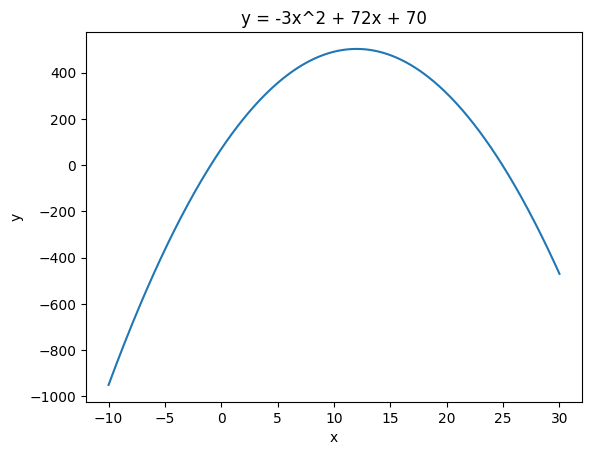

In [48]:
# Plotting Function
x = np.linspace(-10, 30, 400)
plt.plot(x, -3*x**2 + 72*x + 70)
plt.xlabel("x"); plt.ylabel("y")
plt.title("y = -3x^2 + 72x + 70")
plt.show()

## 2.3 Plot $f(x_1, x_2)$.

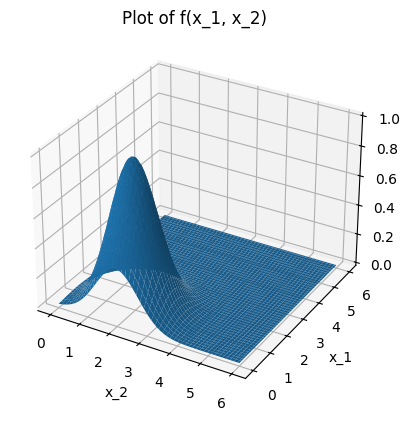

In [51]:
# Make Points
x_1 = np.linspace(0, 6, 100)
x_2 = np.linspace(0, 6, 100)
X_1, X_2 = np.meshgrid(x_1, x_2)
H = np.exp(-(X_1 - 2)**2 - (X_2 - 1)**2)

# Plot Function
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X_1, X_2, H)
plt.xlabel("x_2"); plt.ylabel("x_1")
plt.title("Plot of f(x_1, x_2)")
plt.show()

## 3.1(b) Draw from joint distribution of $(S, W)$ and generate bivariate histogram.

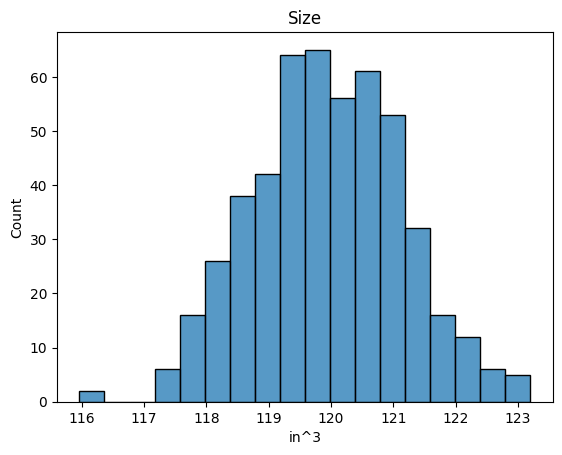

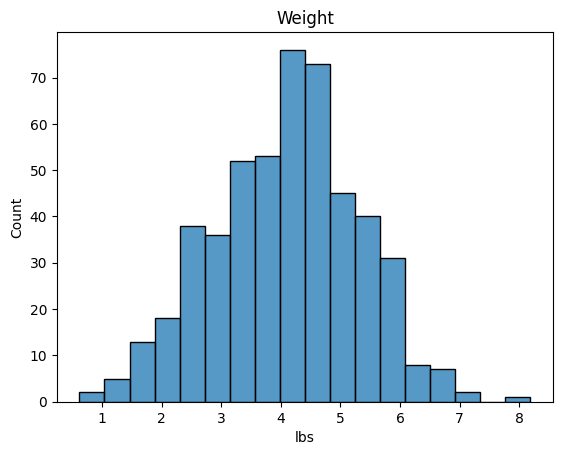

In [54]:
# Create RVs
mean = [120, 4]
cov = [[1.5, 1], [1, 1.5]]
samples = mvn.rvs(mean, cov, 500)

# Plot Histograms
sns.histplot(samples[:, 0])
plt.title("Size")
plt.xlabel("in^3")
plt.show()

sns.histplot(samples[:, 1])
plt.title("Weight")
plt.xlabel("lbs")
plt.show()


## 3.2 Plot the joint PDFs at $S=118$ and $S=122$, varying $W$.

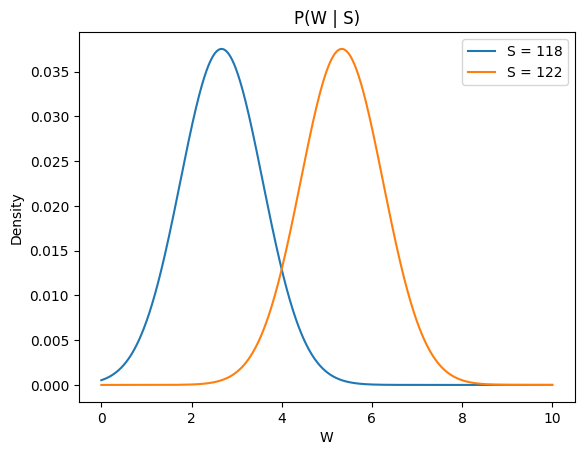

In [55]:
# Establish Parameters and Get Points
w = np.linspace(0, 10, 1001)
s = np.full_like(w, 118)
pdf_vals = mvn.pdf(np.column_stack((s, w)), mean, cov)

# Plot PDF of Joint MVN for S = 118
plt.plot(w, pdf_vals, label= "S = 118")
plt.xlabel("W")
plt.ylabel("Density")
plt.title("P(W | S)")

# Add Plot PDF of Joint MVN for S = 122
s = np.full_like(w, 122)
pdf_vals = mvn.pdf(np.column_stack((s, w)), mean, cov)
plt.plot(w, pdf_vals, label= "S = 122")
plt.legend()
plt.show()


## 3.5(a) Function to simulate draws from $T^{*}$.

In [84]:
# Declare Function
def sim_draw():
    N = np.random.poisson(3.0, 24)
    return sum(np.random.binomial(N, 0.5))

## 3.5(b) Empirically estimate the mean and standard deviation of $T^{*}$ by generating $1000$ samples.

In [125]:
# Generate 1,000 samples & Get stats
T = np.array([sim_draw() for _ in range(1000)])
print("Mean:", np.mean(T)); print("Variance:", np.std(T))

Mean: 35.992
Variance: 5.792575938216089


# 4.1: Examining the Data

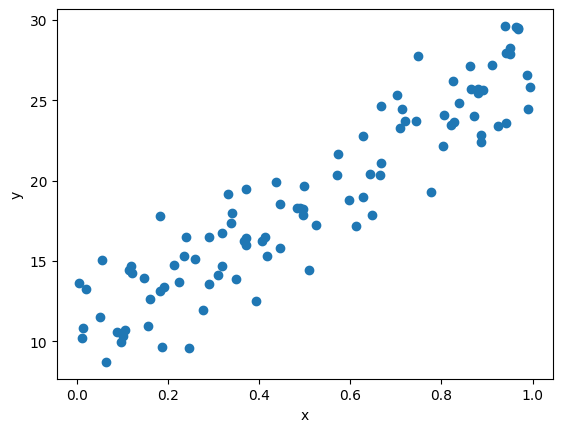

In [97]:
# Steve's solution
data = pd.read_csv("data/points.csv").values
x = data[:, 0]
y = data[:, 1]

# Plot Data
fig, ax = plt.subplots()
ax.scatter(x, y)
plt.xlabel("x"); plt.ylabel("y")
plt.show()

## 4.2: Adding the Intercept/Bias Term

In [111]:
# Steve's solution
x = x.reshape(-1, 1)
intercept = np.ones(x.shape)
X = np.hstack([intercept, x]) # horizontally stack the ones and x coordinates next to each other
print("y:", y.shape); print("X:", X.shape)

y: (100,)
X: (100, 2)


## 4.4: Implementing the LinearRegression Class

In [119]:
# Steve's solution
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        """
        Fit linear model to the data, estimating weights w.
        """
        self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        """
        Use fitted weights to predict target y given input features X.
        """
        return X @ self.w

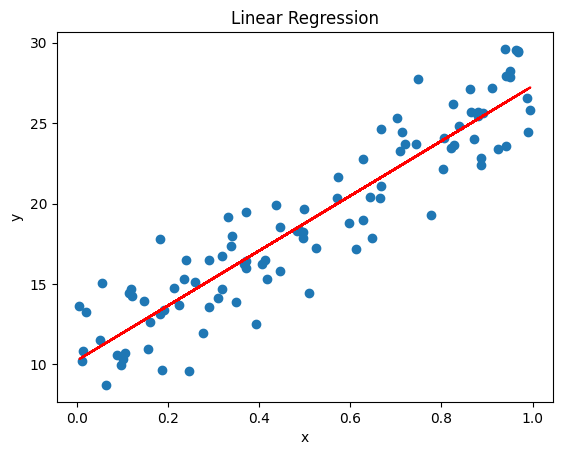

In [121]:
### DON'T MODIFY THIS CELL

# Fit the linear regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
# Plot the data and the regression line
plt.scatter(X[:, 1], y)
plt.plot(X[:, 1], y_pred, color='red')
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig('img_output/hw0_p4_4.png')
plt.show()

## 4.5 MSE Computation

In [124]:
# Steve's solution
mse = 0
for i in range(len(y)):
    mse = mse + (y[i] - y_pred[i])**2
mse = mse / len(y)
print(mse)

4.439331220193986


In [123]:
mse = (1 / len(y)) * np.sum((y - y_pred) ** 2)
print(mse)

4.439331220193985
